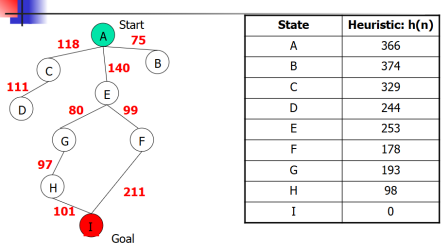

In [ ]:
##Easy style:

import heapq

def heuristic(start, h):
    return h[start]

def build_path(parent, goal):
    path = [goal]
    while parent[goal] is not None:
        goal = parent[goal]
        path = [goal] + path
    return path

def astar_search(start, goal, graph, h):
    g = {start: 0}
    parent = {start: None}
    visited = []
    pq = [(heuristic(start, h), start)]

    while pq:
        f, current = heapq.heappop(pq)

        if current in visited:
            continue
        visited.append(current)

        if current == goal:
            return build_path(parent, goal), g[goal]

        for neighbor, cost in graph.get(current, []):
            if neighbor not in visited:
                new_g = g[current] + cost

                if neighbor not in g or new_g < g[neighbor]:
                    g[neighbor] = new_g
                    parent[neighbor] = current
                    new_f = new_g + heuristic(neighbor, h)
                    heapq.heappush(pq, (new_f, neighbor))

    return None, float("inf")

h = {
    "A": 366, "B": 374, "C": 329, "D": 244,
    "E": 253, "F": 178, "G": 193, "H": 98, "I": 0
}

graph = {
    "A": [("B", 75), ("C", 118), ("E", 140)],
    "B": [],
    "C": [("D", 111)],
    "D": [],
    "E": [("G", 80), ("F", 99)],
    "F": [("I", 211)],
    "G": [("H", 97)],
    "H": [("I", 101)],
    "I": []
}

path, cost = astar_search("A", "I", graph, h)

print(path)
print(cost)

['A', 'E', 'G', 'H', 'I']
418


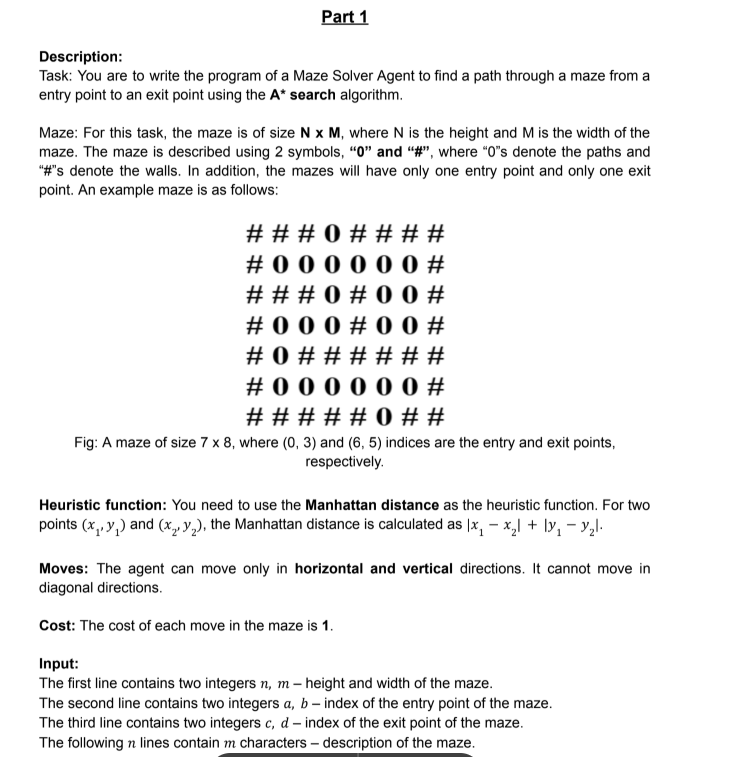


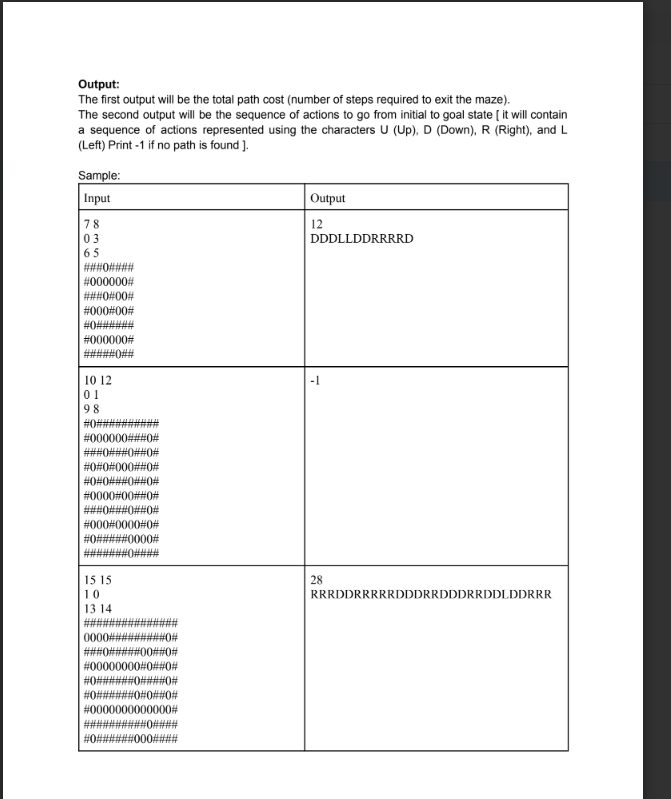

In [ ]:
#Easy code
import heapq

def heuristic(node, goal):
    x1, y1 = node
    x2, y2 = goal
    return abs(x1 - x2) + abs(y1 - y2)

def build_path(parent, goal):
    path = ""
    while parent[goal] is not None:
        goal, move = parent[goal]
        path = move + path
    return path

def astar_search(start, goal, maze, n, m):
    g = {start: 0}
    parent = {start: None}
    visited = []
    pq = [(heuristic(start, goal), start)]

    moves = [(-1, 0, 'U'), (1, 0, 'D'), (0, -1, 'L'), (0, 1, 'R')]

    while pq:
        f, current = heapq.heappop(pq)

        if current in visited:
            continue
        visited.append(current)

        if current == goal:
            return g[goal], build_path(parent, goal)

        x, y = current

        for dx, dy, move in moves:
            nx, ny = x + dx, y + dy
            neighbor = (nx, ny)

            if 0 <= nx < n and 0 <= ny < m and maze[nx][ny] == '0':
                if neighbor not in visited:
                    new_g = g[current] + 1

                    if neighbor not in g or new_g < g[neighbor]:
                        g[neighbor] = new_g
                        parent[neighbor] = (current, move)
                        new_f = new_g + heuristic(neighbor, goal)
                        heapq.heappush(pq, (new_f, neighbor))

    return -1, ""

n, m = 7, 8
start = (0, 3)
goal = (6, 5)

maze = [
    "###0####",
    "#000000#",
    "###0#00#",
    "#000#00#",
    "#0######",
    "#000000#",
    "#####0##"
]

cost, path = astar_search(start, goal, maze, n, m)

print(cost)
if cost != -1:
    print(path)

12
DDDLLDDRRRRD


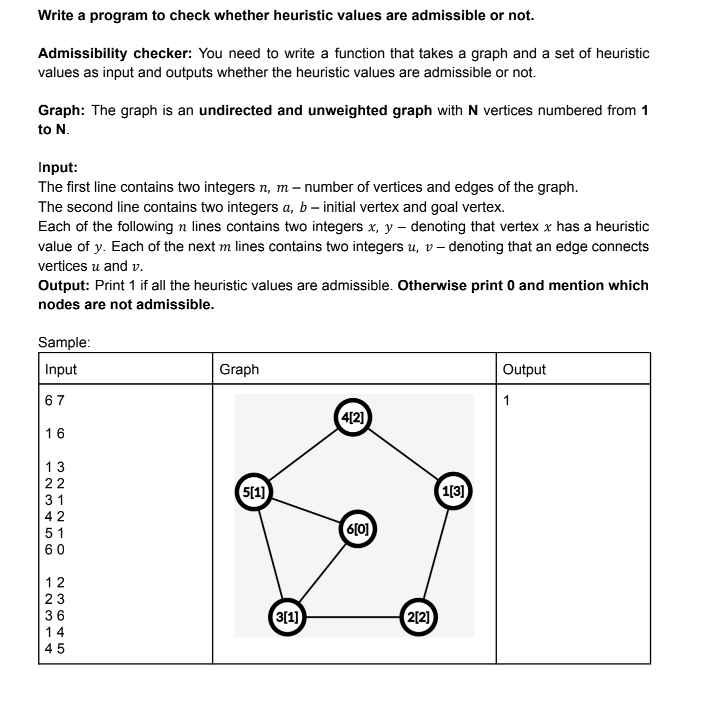

In [ ]:
import heapq

def a_star(start, goal, graph):
    g = {start: 0}
    visited = []
    pq = [(0, start)]

    while pq:
        f, current = heapq.heappop(pq)

        if current in visited:
            continue
        visited.append(current)

        if current == goal:
            return g[goal]

        for neighbor in graph[current]:
            if neighbor not in visited:
                new_g = g[current] + 1

                if neighbor not in g or new_g < g[neighbor]:
                    g[neighbor] = new_g
                    heapq.heappush(pq, (new_g, neighbor))

    return float("inf")

def check_admissible(goal, graph, heuristics, n):
    bad = []

    for node in range(1, n + 1):
        real_cost = a_star(node, goal, graph)

        if heuristics[node] > real_cost:
            bad.append(node)

    if len(bad) == 0:
        print(1)
    else:
        print(0)
        print("Not admissible nodes:", bad)

n = 6
goal = 6

heuristics = {
    1: 3,
    2: 2,
    3: 1,
    4: 2,
    5: 1,
    6: 0
}

graph = {
    1: [2, 4],
    2: [1, 3],
    3: [2, 6, 5],
    4: [1, 5],
    5: [4, 3],
    6: [3]
}

check_admissible(goal, graph, heuristics, n)

1


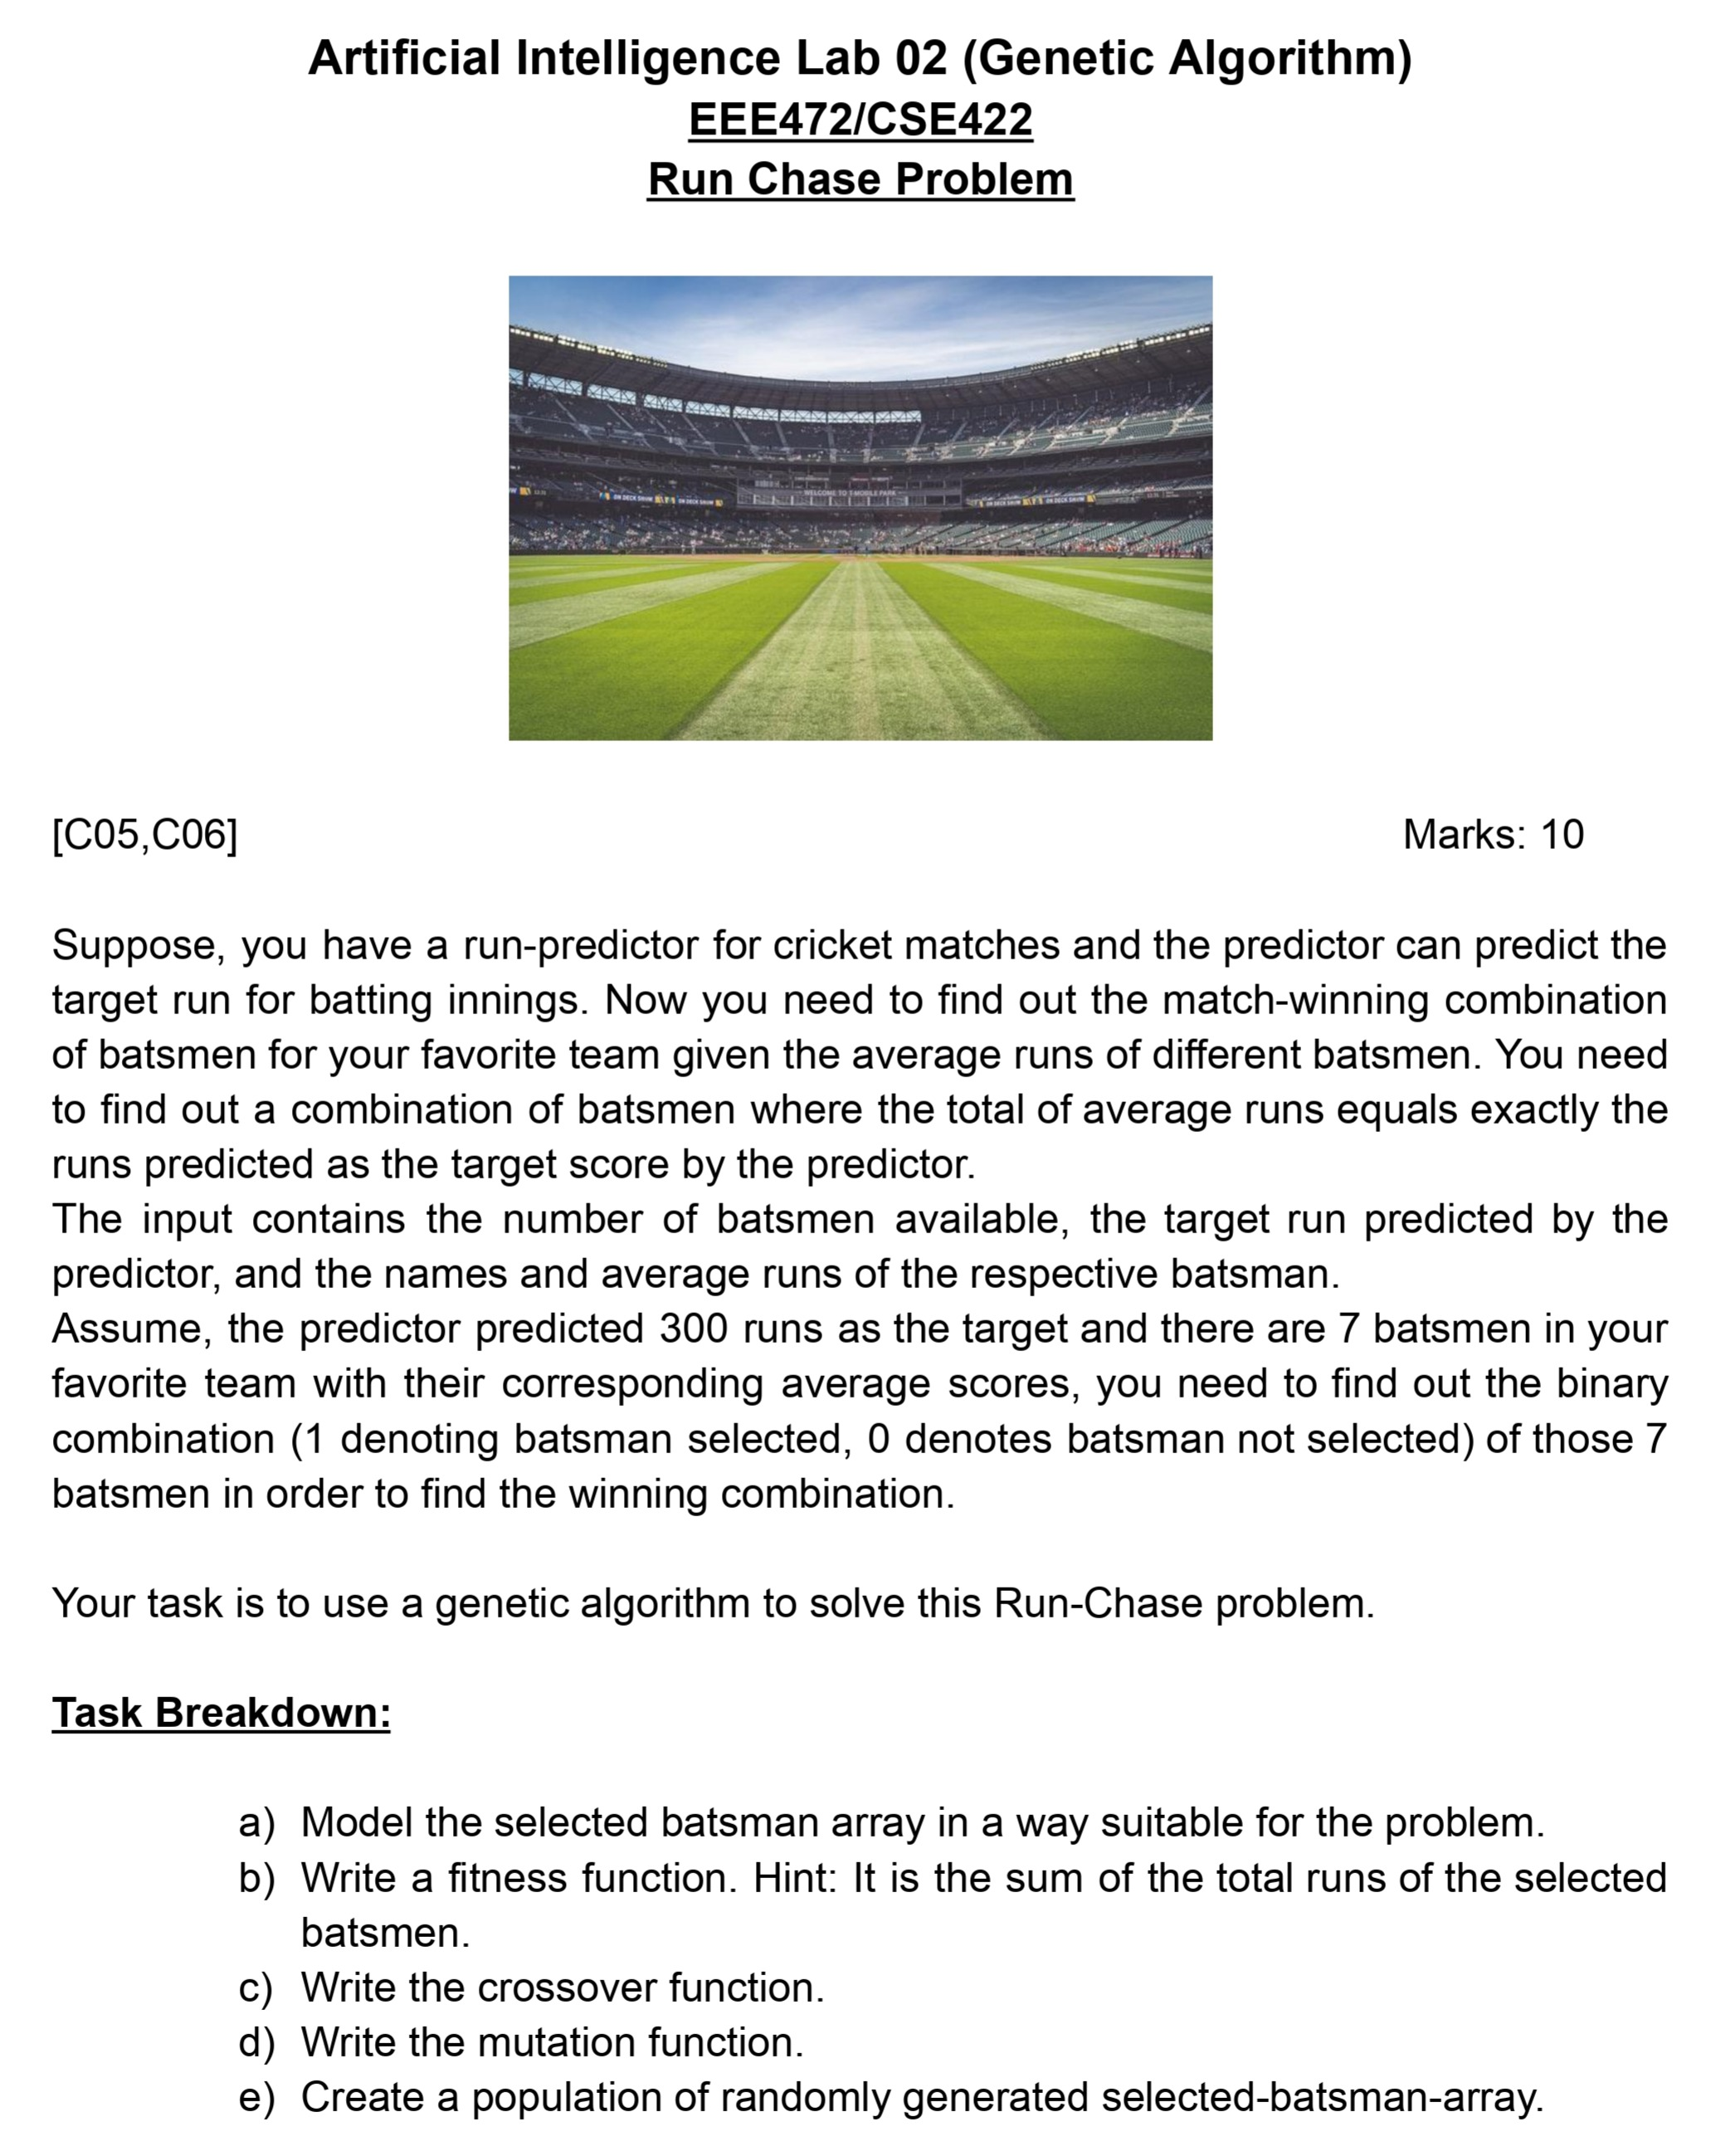

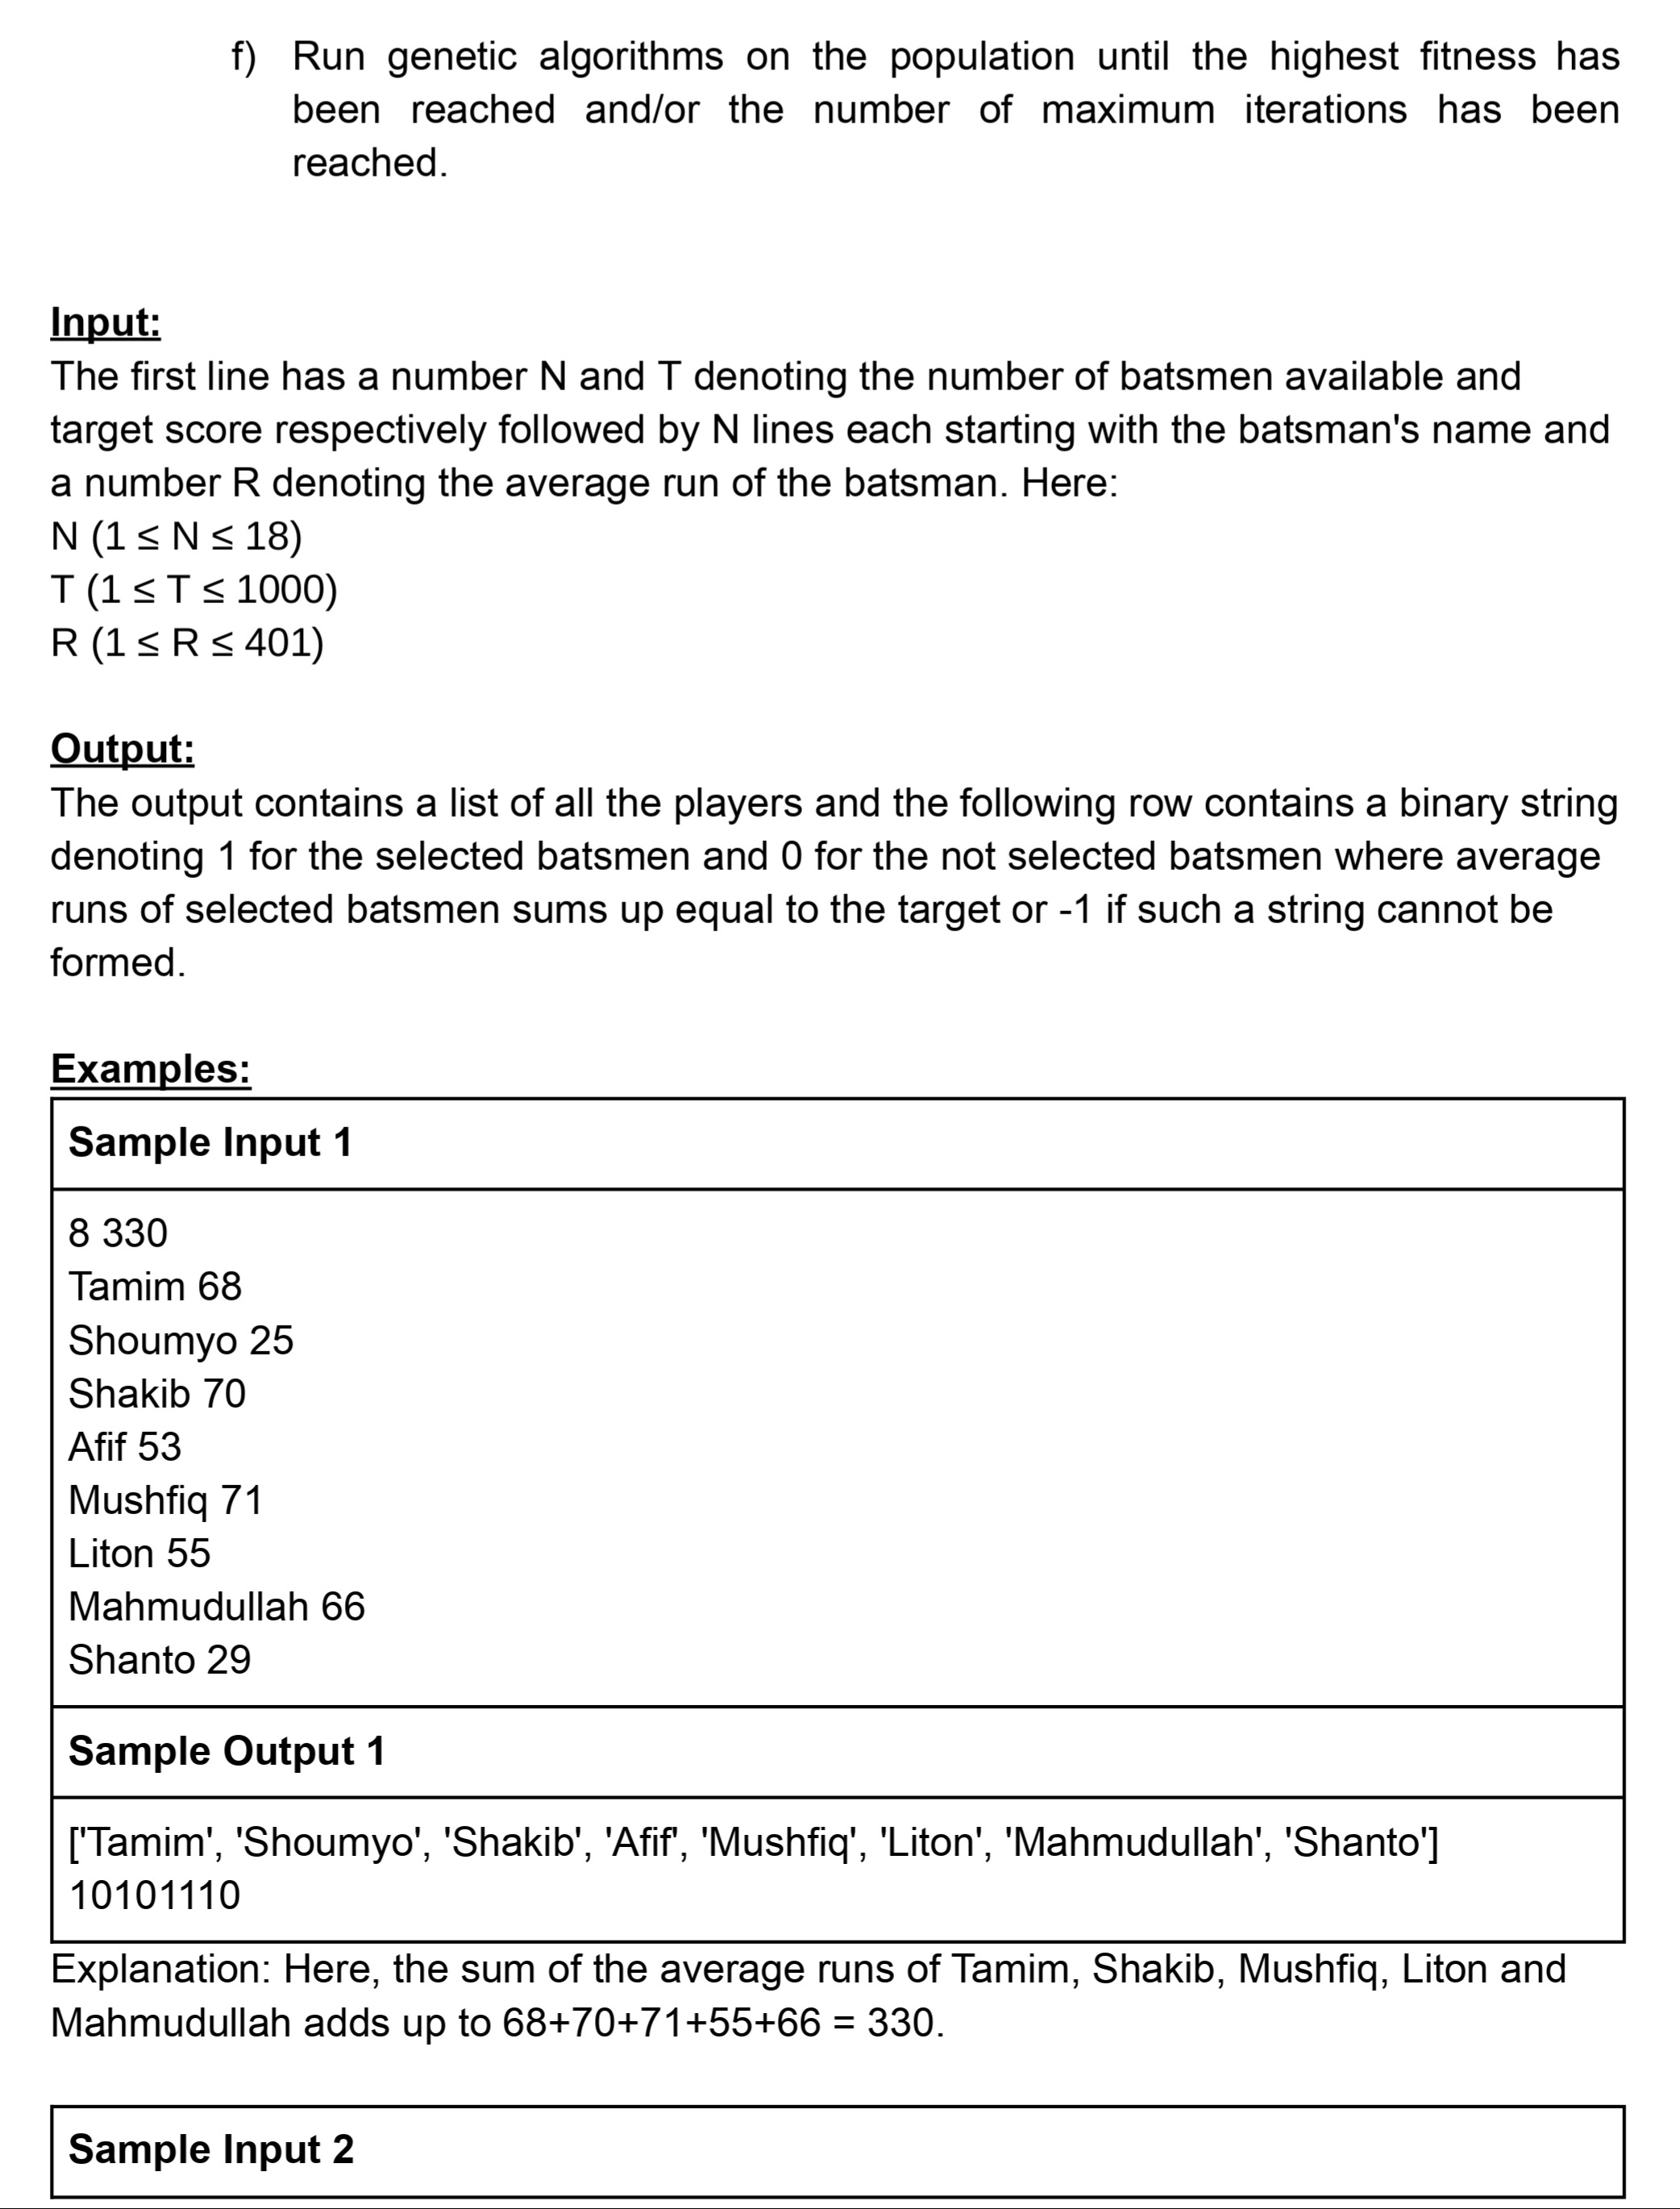

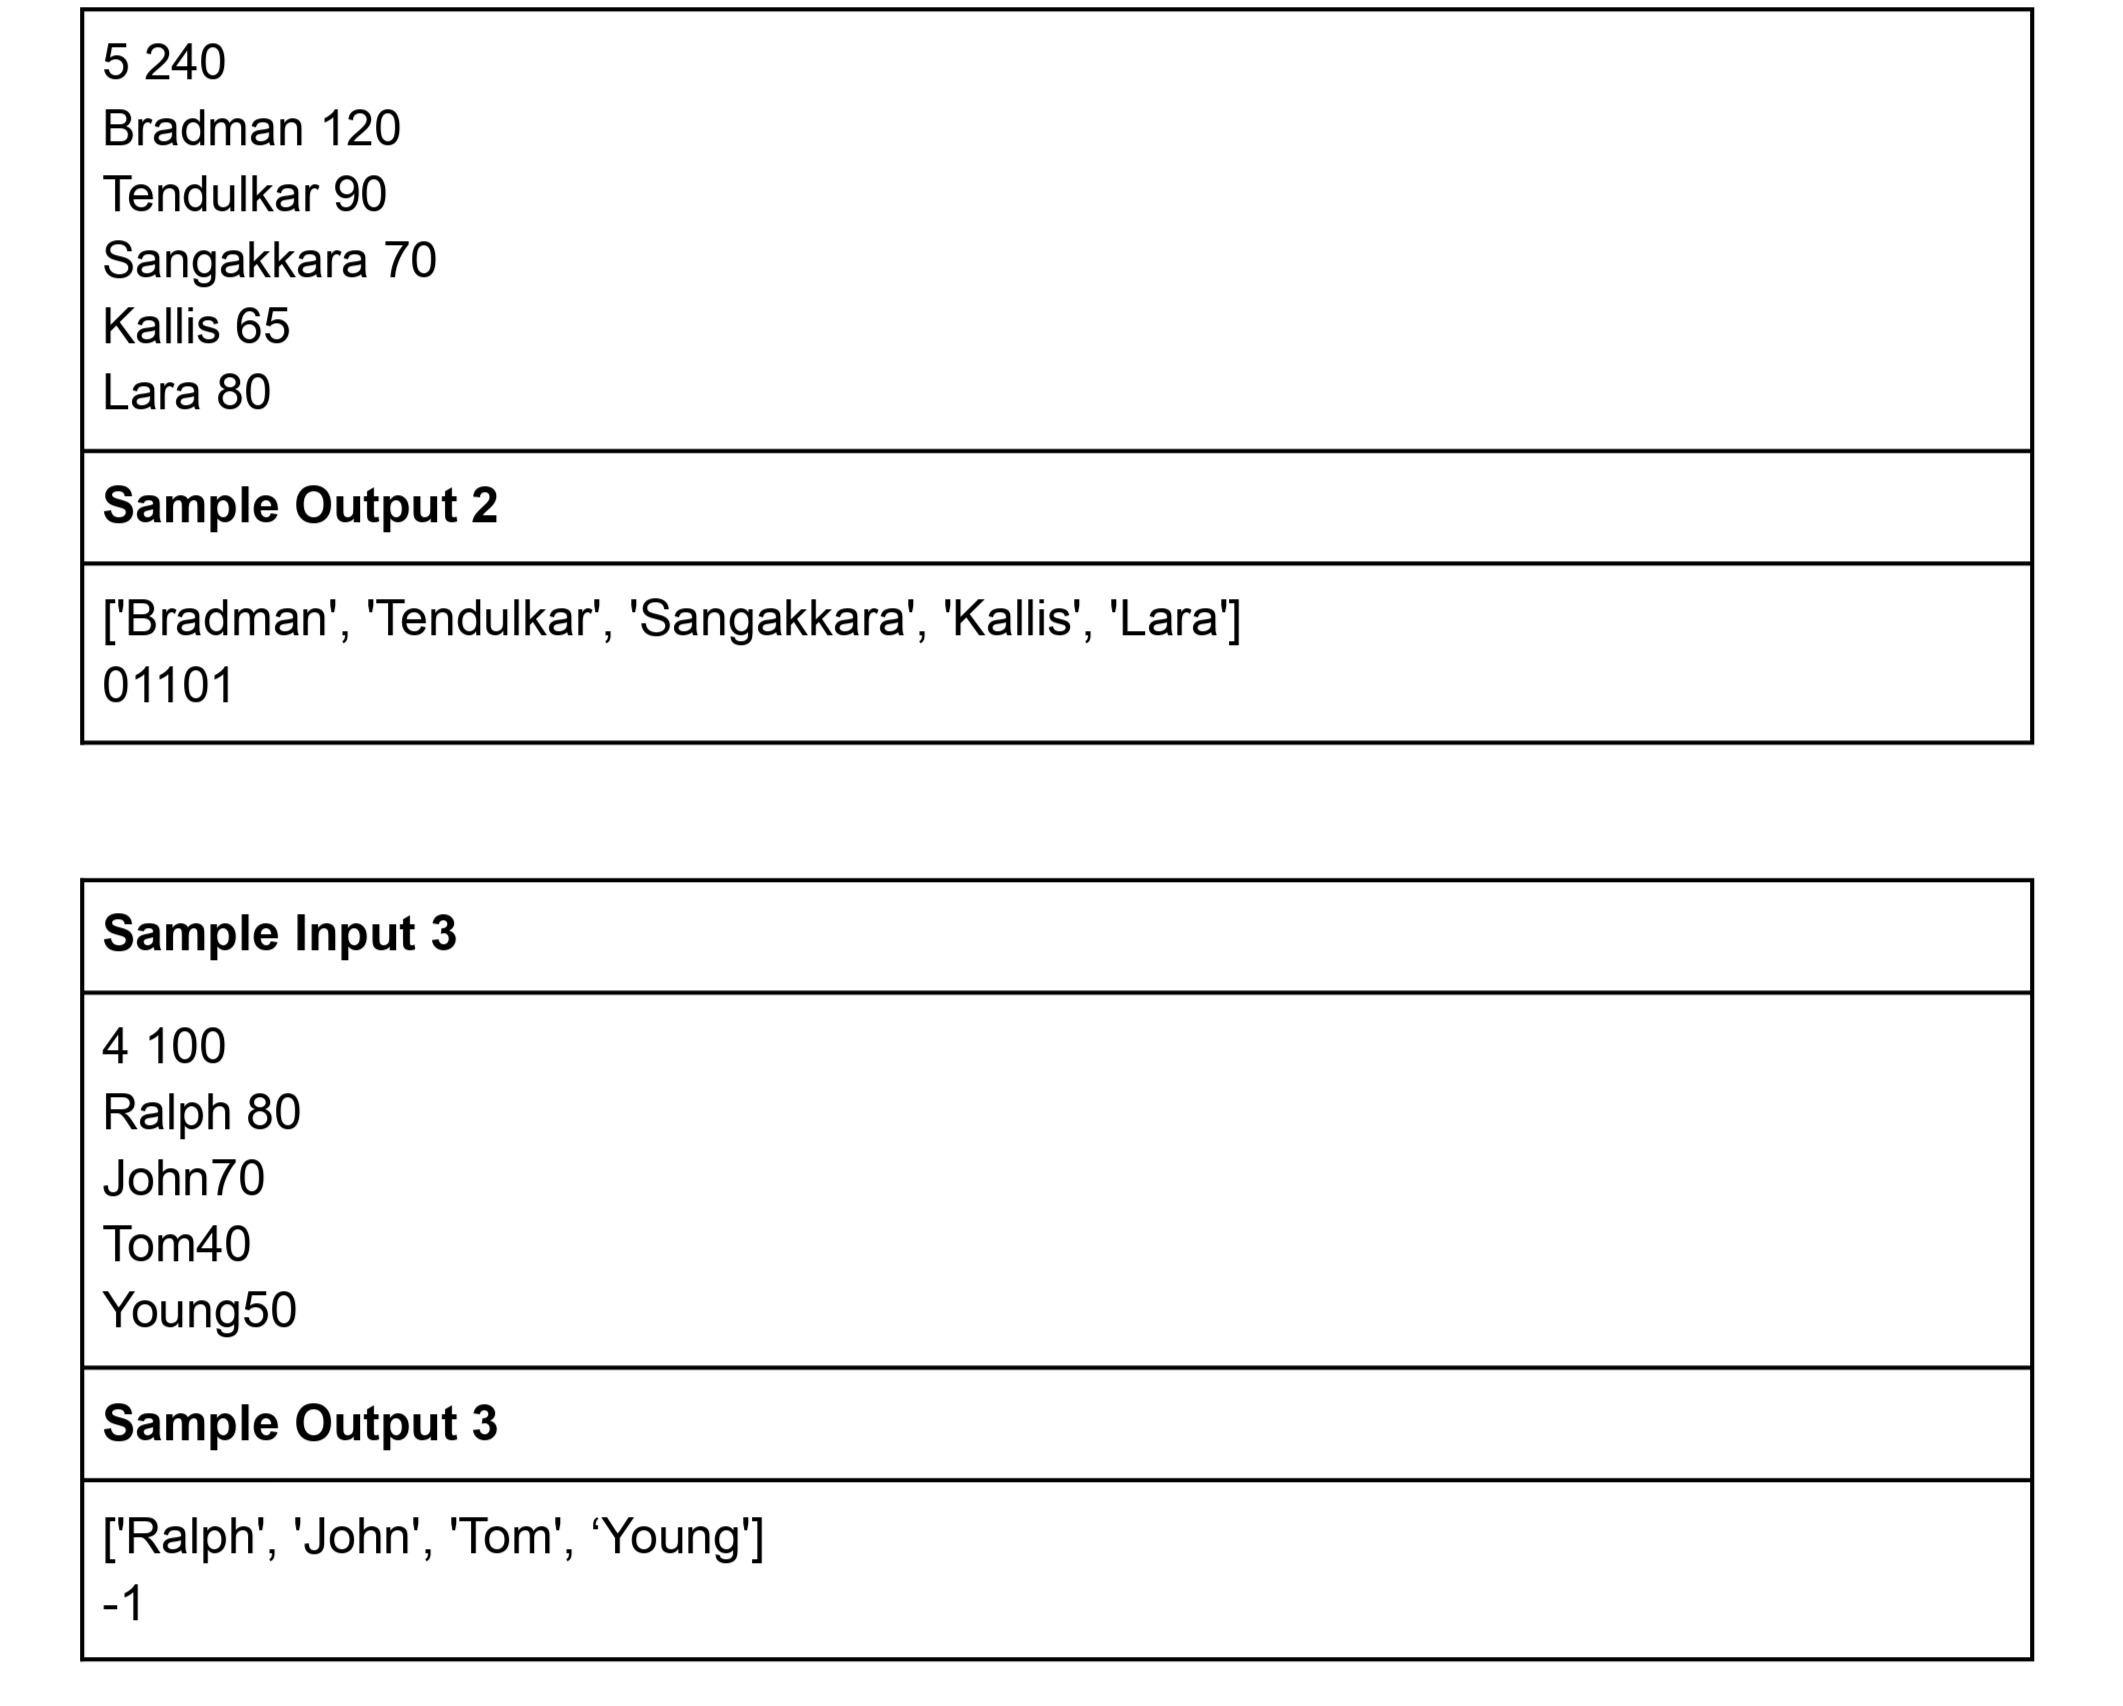

In [ ]:
# Genetic Algorithm

''' 1. pop
    2. fit
    3. crossover
    4. mutate
    5. GA '''

import random

def POP (data, limit):
    population = []
    for i in range(limit):
        chromosome = []
        for i in range(len(data)):
            bit = random.randint(0,1)
            chromosome.append(bit)
        population.append(chromosome)
    return population

def fitness(chromosome, target, run):
    score = 0
    for i in range(len(chromosome)):
        if chromosome[i] == 1:
            score += int(run[i])
    return abs(score - target)

def crossover(p1, p2):
    bit = random.randint(1,6)
    c1 = p1[:bit] + p2[bit:]
    c2 = p2[:bit] + p1[bit:]
    return c1, c2

def mutate(chromosome, rate):
    if random.random() < rate:
        bit = random.randint(0, len(chromosome)-1)
        chromosome[bit] = 1 - chromosome[bit]
    return chromosome

def GA(data, target):
    pop_limit = 10
    max_iter = 10000
    mrate = 0.2

    name= list(data.keys())
    run = list(data.values())

    population = POP(data, pop_limit)

    for i in range(max_iter):
        for i in population:
            if fitness(i, target, run) == 0:
                return name, i

        newPopulation = []
        while len(newPopulation) < pop_limit:
            parent1, parent2 = random.sample(population, 2)
            child1, child2 = crossover(parent1, parent2)
            c1, c2 = mutate(child1, mrate), mutate(child2, mrate)

            if fitness(c1, target, run) == 0:
                return name, c1
            if fitness(c2, target, run) == 0:
                return name, c2

            newPopulation+= [c1, c2]

        population = newPopulation #imp

    return name, -1





# --- Fixed Input Driver Code ---
if __name__ == "__main__":
    # Sample Input 1 from Lab Manual
    # Target: 330
    # Players: Tamim 68, Shoumyo 25, Shakib 70, Afif 53, Mushfiq 71, Liton 55, Mahmudullah 66, Shanto 29

    target_score = 330
    batsmen_data = {
        'Tamim': 68,
        'Shoumyo': 25,
        'Shakib': 70,
        'Afif': 53,
        'Mushfiq': 71,
        'Liton': 55,
        'Mahmudullah': 66,
        'Shanto': 29
    }

    print(f"Target Score: {target_score}")
    print("Batsmen Data:", batsmen_data)
    print("-" * 30)

    players, result = GA(batsmen_data, target_score)

    if result != -1:
        print(f"Players: {players}")
        print(f"Binary Result: {result}")
    else:
        print("No solution found.")

Target Score: 330
Batsmen Data: {'Tamim': 68, 'Shoumyo': 25, 'Shakib': 70, 'Afif': 53, 'Mushfiq': 71, 'Liton': 55, 'Mahmudullah': 66, 'Shanto': 29}
------------------------------
Players: ['Tamim', 'Shoumyo', 'Shakib', 'Afif', 'Mushfiq', 'Liton', 'Mahmudullah', 'Shanto']
Binary Result: [1, 0, 1, 0, 1, 1, 1, 0]


In [ ]:
##Skeleton code

import random

def POP(data, limit):
    population = []
    for i in range(limit):
        chromosome = []
        for j in range(len(data)):
            chromosome.append(random.randint(0, 1))
        population.append(chromosome)
    return population

def fitness(chromosome, target, run):
    score = 0
    for i in range(len(chromosome)):
        if chromosome[i] == 1:
            score += run[i]
    return abs(score - target)

def crossover(p1, p2):
    bit = random.randint(1, len(p1) - 1)
    c1 = p1[:bit] + p2[bit:]
    c2 = p2[:bit] + p1[bit:]
    return c1, c2

def mutate(chromosome, rate):
    if random.random() < rate:
        bit = random.randint(0, len(chromosome) - 1)
        chromosome[bit] = 1 - chromosome[bit]
    return chromosome

def GA(data, target):
    pop_limit = 10
    max_iter = 10000
    mrate = 0.2

    name = list(data.keys())
    run = list(data.values())

    population = POP(data, pop_limit)

    for i in range(max_iter):
        for chromosome in population:
            if fitness(chromosome, target, run) == 0:
                return name, chromosome

        new_population = []

        while len(new_population) < pop_limit:
            p1, p2 = random.sample(population, 2)
            c1, c2 = crossover(p1, p2)
            c1 = mutate(c1, mrate)
            c2 = mutate(c2, mrate)

            if fitness(c1, target, run) == 0:
                return name, c1
            if fitness(c2, target, run) == 0:
                return name, c2

            new_population += [c1, c2]

        population = new_population

    return name, -1

In [ ]:
# Genetic Algorithm for Grid Path
# 1. pop
# 2. fit
# 3. crossover
# 4. mutate
# 5. GA

import random

moves = ["U", "D", "L", "R"]

def POP(limit, path_len):
    population = []
    for i in range(limit):
        chromosome = []
        for j in range(path_len):
            chromosome.append(random.choice(moves))
        population.append(chromosome)
    return population

def fitness(chromosome, grid, start, goal):
    row, col = start
    cost = 0
    penalty = 0

    for move in chromosome:
        nr, nc = row, col

        if move == "U":
            nr -= 1
        elif move == "D":
            nr += 1
        elif move == "L":
            nc -= 1
        elif move == "R":
            nc += 1

        if nr < 0 or nr >= len(grid) or nc < 0 or nc >= len(grid[0]):
            penalty += 50
        elif grid[nr][nc] == 1:   # road block
            penalty += 50
        else:
            row, col = nr, nc
            cost += 1             # each free block +1

        if (row, col) == goal:
            break

    distance = abs(row - goal[0]) + abs(col - goal[1])
    return cost + penalty + distance * 10

def crossover(p1, p2):
    bit = random.randint(1, len(p1)-1)
    c1 = p1[:bit] + p2[bit:]
    c2 = p2[:bit] + p1[bit:]
    return c1, c2

def mutate(chromosome, rate):
    if random.random() < rate:
        bit = random.randint(0, len(chromosome)-1)
        chromosome[bit] = random.choice(moves)
    return chromosome

def GA(grid, start, goal):
    pop_limit = 10
    max_iter = 1000
    mrate = 0.2
    path_len = 20

    population = POP(pop_limit, path_len)

    for i in range(max_iter):
        population.sort(key=lambda x: fitness(x, grid, start, goal))

        best = population[0]

        if fitness(best, grid, start, goal) <= path_len:
            return best, fitness(best, grid, start, goal)

        newPopulation = []

        while len(newPopulation) < pop_limit:
            parent1, parent2 = random.sample(population[:5], 2)

            child1, child2 = crossover(parent1, parent2)

            child1 = mutate(child1, mrate)
            child2 = mutate(child2, mrate)

            newPopulation += [child1, child2]

        population = newPopulation

    best = min(population, key=lambda x: fitness(x, grid, start, goal))
    return best, fitness(best, grid, start, goal)


# 0 = free road
# 1 = road block
grid = [
    [0, 0, 0, 0],
    [1, 1, 0, 1],
    [0, 0, 0, 0],
    [0, 1, 1, 0]
]

start = (0, 0)
goal = (3, 3)

path, score = GA(grid, start, goal)

print("Best path:", path)
print("Cost:", score)

Best path: ['R', 'R', 'R', 'R', 'L', 'R', 'L', 'R', 'L', 'D', 'D', 'R', 'D', 'U', 'U', 'D', 'R', 'L', 'L', 'L']
Cost: 62


In [ ]:
import random

def two_point_crossover_random(parent1, parent2):
    bit1 = random.randint(1, len(parent1)-2)
    bit2 = random.randint(bit1+1, len(parent1)-1)

    c1 = parent1[:bit1] + parent2[bit1:bit2] + parent1[bit2:]
    c2 = parent2[:bit1] + parent1[bit1:bit2] + parent2[bit2:]

    return c1, c2

# **Story Background**

This is the year **2082**. Robots have taken over the world, and the *International Robot Sports Committee (IRSC)* has been hosting Robot Olympics for a decade.
In the *ROBO Sword-Fight* event, two robots face off using swords.

**Optimus Prime** has dominated all previous matches. Only one match remains—against **Megatron**.
To win, Optimus must reach a specific number of points.

You will perform **two tasks using Alpha-Beta Pruning**.

---

## **Tasks**

### **Task 1 — Winner Calculation (6 marks)**

* Use **Alpha-Beta Pruning** on a **4-level binary tree**:

  * **Level 0 (MAX)** → Optimus Prime
  * **Level 1 (MIN)** → Megatron
  * **Level 2 (MAX)** → Optimus Prime
  * **Level 3** → Terminal Nodes (random point values)

* Calculate:

  1. The terminal node values
  2. The final score from Alpha-Beta pruning
  3. Whether Optimus wins

[How to find the winner: As the achieved point by Optimus Prime is 73 which is greater than 56, Optimus Prime wins. If the Achieved point by applying alpha-beta pruning >= Total points to win, then Winner is Optimus Prime. Otherwise, the Winner is Megatron]


---

### **Task 2 — Shuffle Simulation (4 marks)**

* Shuffle the **8 generated terminal values** **S times**
* Each shuffle gives a new leaf order for the Alpha-Beta tree
* Count how many times Optimus wins

Where **S = 4th digit of your student ID**
(If digit is `0`, use `8` instead)

---

## **Important Rules**

If any digit of the student ID is **0**, consider it as **8**.

---
---
---

# **Sample Input 1**

```
Enter your student ID
25485465
```

---

# **Sample Output 1 – Task 1**

```
Generated 8 random points between the minimum and maximum point limits:
[66, 74, 14, 73, 19, 26, 32, 40]

Total points to win: 56
Achieved point by applying alpha-beta pruning = 73

The winner is Optimus Prime
```

---

# **Sample Output 1 – Task 2**

```
After the shuffle:
List of all points from each shuffle:
[66, 73, 66, 73, 73, 66, 40, 66]

Maximum value of all shuffles: 73
Won 7 times out of 8 shuffles
```

### **Explanation**

* **5th digit of ID (25485465)** = **5** → Minimum points = 5
* Reverse last two digits = **65 → 56**

  * Multiply by 1.5 → 84
  * Upper nearest integer → **84** → Maximum points
* Total points to win = **56**
* Number of shuffles = **4th digit = 8**

---

# **Sample Input 2**

```
Enter your student ID
17564039
```

---

# **Sample Output 2**

```
Generated 8 random points:
[36, 26, 112, 57, 85, 80, 107, 28]

Total points to win: 93
Achieved point = 85

Winner: Megatron
```

```
After the shuffle:
List: [107, 80, 85, 80, 85, 107]

Maximum value: 107
Won 2 times out of 6 shuffles
```


In [ ]:
import math
import random

MAX = 999999
MIN = -999999

def minimax(depth, index, is_max, tree, alpha, beta):
    if depth == 3:
        return tree[index]

    if is_max:
        best = MIN
        for i in range(2):
            best = max(best, minimax(depth + 1, index * 2 + i, False, tree, alpha, beta))
            alpha = max(alpha, best)
            if alpha >= beta:
                break
        return best
    else:
        best = MAX
        for i in range(2):
            best = min(best, minimax(depth + 1, index * 2 + i, True, tree, alpha, beta))
            beta = min(beta, best)
            if alpha >= beta:
                break
        return best


student_id = "23201642"
new_id = student_id.replace("0", "8")

min_value = int(new_id[4])
target = int(new_id[-1] + new_id[-2])
max_value = math.ceil(target * 1.5)
shuffle_times = int(new_id[3])

random.seed(42)   # fixed output
leaf_nodes = [random.randint(min_value, max_value) for _ in range(8)]

print("Generated leaf nodes:", leaf_nodes)
print("Points to win:", target)

achieved = minimax(0, 0, True, leaf_nodes, MIN, MAX)
print("Achieved point by alpha-beta pruning =", achieved)

if achieved >= target:
    print("The Winner is Optimus Prime")
else:
    print("The Winner is Megatron")

print("-" * 40)
print("After shuffle:")

results = []
wins = 0

for i in range(shuffle_times):
    random.shuffle(leaf_nodes)
    value = minimax(0, 0, True, leaf_nodes, MIN, MAX)
    results.append(value)
    if value >= target:
        wins += 1

print("Shuffle results:", results)
print("Maximum value:", max(results))
print("Won", wins, "times out of", shuffle_times)

Generated leaf nodes: [8, 2, 18, 16, 15, 9, 7, 35]
Points to win: 24
Achieved point by alpha-beta pruning = 15
The Winner is Megatron
----------------------------------------
After shuffle:
Shuffle results: [15, 16, 18, 18, 16, 15, 18, 16]
Maximum value: 18
Won 0 times out of 8


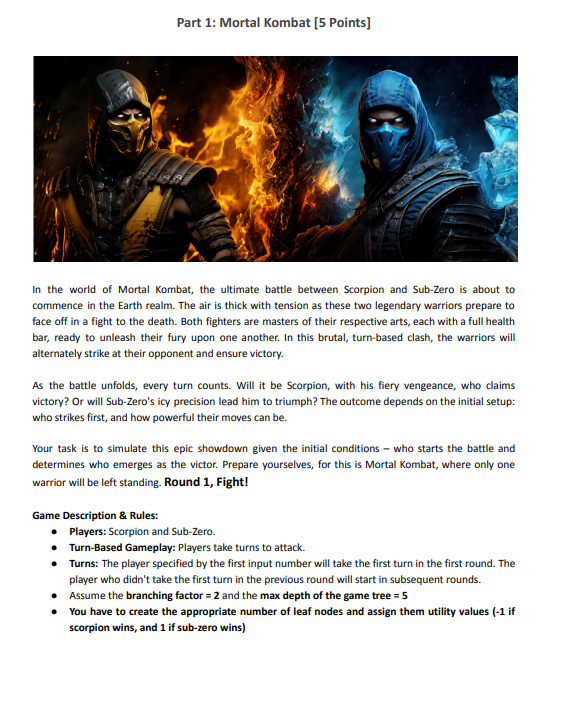

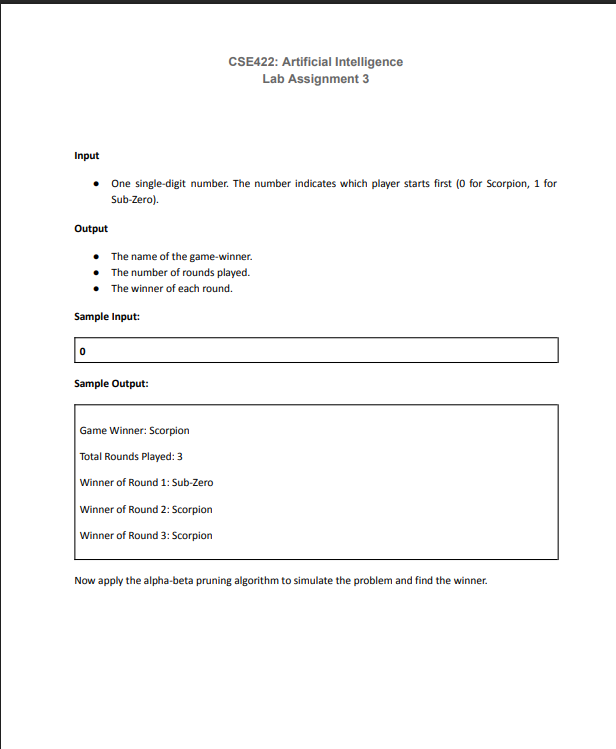

In [ ]:
MAX = 999999
MIN = -999999

def minimax(depth, index, is_max, tree, alpha, beta,max_depth):
    if depth == max_depth:
        return tree[index]

    if is_max:
        best = MIN
        for i in range(2):
            best = max(best, minimax(depth + 1, index * 2 + i, False, tree, alpha, beta,max_depth))
            alpha = max(alpha, best)
            if alpha >= beta:
                break
        return best
    else:
        best = MAX
        for i in range(2):
            best = min(best, minimax(depth + 1, index * 2 + i, True, tree, alpha, beta,max_depth))
            beta = min(beta, best)
            if alpha >= beta:
                break
        return best

max_depth=5

first_player = 0   # 0 = Scorpion starts, 1 = Sub-Zero starts
trees = [
    [1] * 32,    # Round 1 -> Sub-Zero
    [-1] * 32,   # Round 2 -> Scorpion
    [-1] * 32    # Round 3 -> Scorpion
]

scorpion_wins = 0
subzero_wins = 0
round_winners = []

for tree in trees:
    result = minimax(0, 0, first_player == 1, tree, MIN, MAX,max_depth)
    if result == 1:
      winner = "Sub-Zero"
    else:
      winner= "Scorpion"
    round_winners.append(winner)

    if winner == "Scorpion":
        scorpion_wins += 1
    else:
        subzero_wins += 1

    if scorpion_wins == 2 or subzero_wins == 2:
        break

    first_player = 1 - first_player

if scorpion_wins > subzero_wins:
  game_winner = "Scorpion"
else:
  game_winner ="Sub-Zero"

print("Game Winner:", game_winner)
print("Total Rounds Played:", len(round_winners))
for i in range(len(round_winners)):
    print("Winner of Round", i + 1, ":", round_winners[i])

Game Winner: Scorpion
Total Rounds Played: 3
Winner of Round 1 : Sub-Zero
Winner of Round 2 : Scorpion
Winner of Round 3 : Scorpion


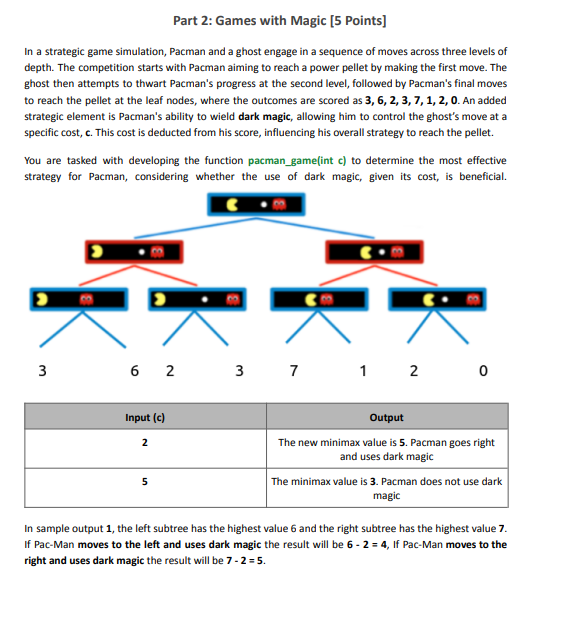

In [ ]:
MAX = 999999
MIN = -999999

def minimax(depth, index, is_max,leaf, alpha, beta,max_depth):
    if depth == max_depth:
        return leaf[index]

    if is_max:
        best = MIN
        for i in range(2):
            val =  minimax(depth + 1, index * 2 + i, False,leaf, alpha, beta,max_depth)
            best=max(val,best)
            alpha = max(alpha, best)
            if alpha >= beta:
                break
        return best
    else:
        best = MAX
        for i in range(2):
            val =  minimax(depth + 1, index * 2 + i, True,leaf, alpha, beta,max_depth)
            best=min(val,best)
            beta = min(beta, best)
            if alpha >= beta:
                break
        return best

leaf = [3, 6, 2, 3, 7, 1, 2, 0]

c = 2   # hardcoded cost
max_depth=3

value = minimax(0, 0, True, leaf,MIN, MAX,max_depth)

left = max(leaf[0], leaf[1], leaf[2], leaf[3]) - c
right = max(leaf[4], leaf[5], leaf[6], leaf[7]) - c

magic = max(left, right)

if magic > value:
  if left >= right:
    direction = "left"
  else:
    direction= "right"
    print("The new minimax value is", magic, ". Pacman goes", direction, "and uses dark magic")
else:
    print("The minimax value is", value, ". Pacman does not use dark magic")

The new minimax value is 5 . Pacman goes right and uses dark magic


In [ ]:
###Standard alpha beta type

MAX = 999999999
MIN = -999999999

def minimax(depth, index, is_max, tree, alpha, beta, max_depth):
    if depth == max_depth:
        return tree[index]

    if is_max:
        best = MIN
        for i in range(2):
            value = minimax(depth + 1, index * 2 + i, False, tree, alpha, beta, max_depth)
            best = max(best, value)
            alpha = max(alpha, best)
            if alpha >= beta:
                break
        return best

    else:
        best = MAX
        for i in range(2):
            value = minimax(depth + 1, index * 2 + i, True, tree, alpha, beta, max_depth)
            best = min(best, value)
            beta = min(beta, best)
            if alpha >= beta:
                break
        return best

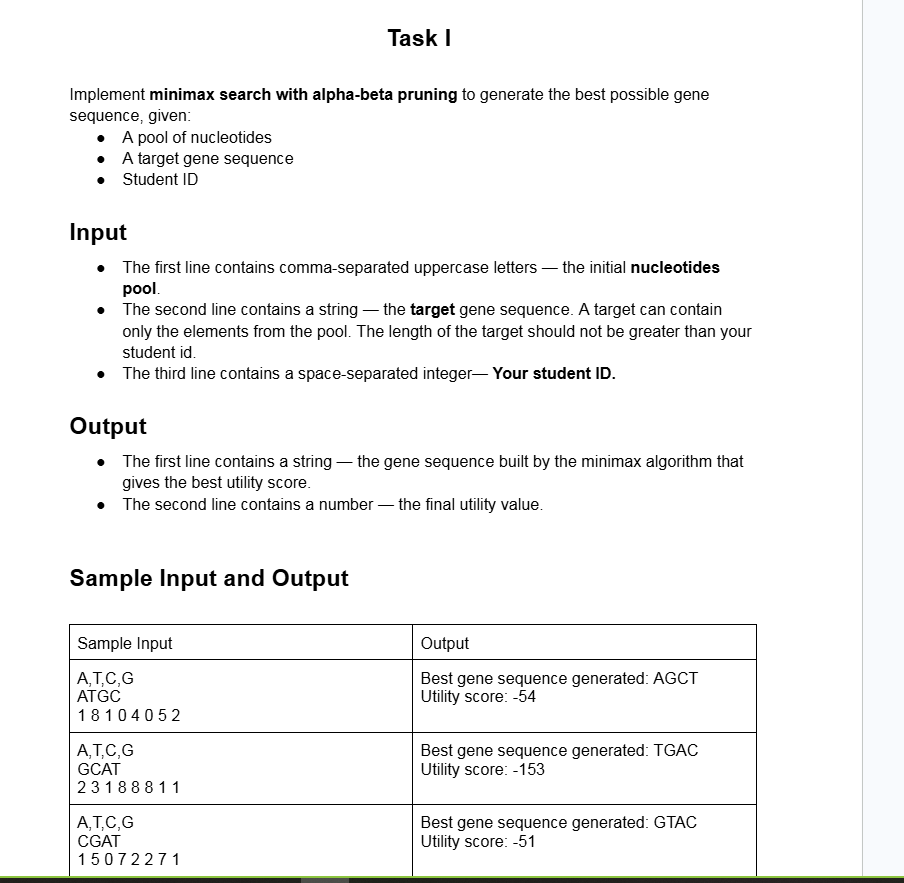

In [ ]:
MAX = 999999999
MIN = -999999999

def utility(sequence, target, weights):
    score = 0
    for i in range(len(target)):
        score += weights[i] * abs(ord(sequence[i]) - ord(target[i]))
    return -score


def minimax(depth, index, is_max, tree, alpha, beta, max_depth):
    pool, target, weights, sequence = tree

    if depth == max_depth:
        return utility(sequence, target, weights), sequence

    if is_max:
        best = MIN
        best_sequence = ""

        for i in range(len(pool)):
            nucleotide = pool[i]
            new_pool = pool[:i] + pool[i+1:]
            new_tree = [new_pool, target, weights, sequence + nucleotide]

            value, seq = minimax(depth + 1, index, False, new_tree, alpha, beta, max_depth)

            old_best = best
            best = max(best, value)

            if best != old_best:
                best_sequence = seq

            alpha = max(alpha, best)

            if alpha >= beta:
                break

        return best, best_sequence

    else:
        best = MAX
        best_sequence = ""

        for i in range(len(pool)):
            nucleotide = pool[i]
            new_pool = pool[:i] + pool[i+1:]
            new_tree = [new_pool, target, weights, sequence + nucleotide]

            value, seq = minimax(depth + 1, index, True, new_tree, alpha, beta, max_depth)

            old_best = best
            best = min(best, value)

            if best != old_best:
                best_sequence = seq

            beta = min(beta, best)

            if alpha >= beta:
                break

        return best, best_sequence


# hardcoded input
pool = ["A", "T", "C", "G"]
target = "ATGC"
student_id = [1, 8, 1, 0, 4, 0, 5, 2]

weights = student_id[-len(target):]

tree = [pool, target, weights, ""]

value, sequence = minimax(0, 0, True, tree, MIN, MAX, len(target))

print("Best gene sequence generated:", sequence)
print("Utility score:", value)

Best gene sequence generated: AGCT
Utility score: -54


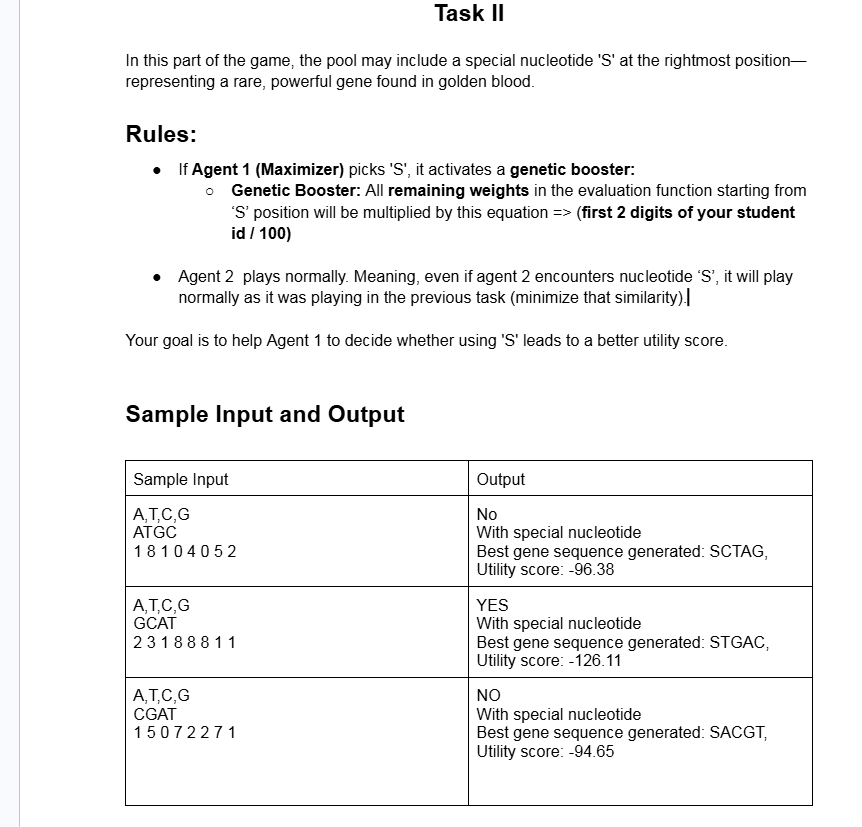

In [ ]:
MAX = 999999999
MIN = -999999999

def utility(gene, target, weights, booster, s_pos, factor):
    new_weights = weights[:]

    if booster and s_pos != -1:
        for i in range(s_pos, len(new_weights)):
            new_weights[i] = new_weights[i] * factor

    n = max(len(gene), len(target))
    score = 0

    for i in range(n):
        w = new_weights[i] if i < len(new_weights) else 1
        g = ord(gene[i]) if i < len(gene) else 0
        t = ord(target[i]) if i < len(target) else 0
        score += w * abs(g - t)

    return -round(score, 2)

def minimax(depth, index, is_max, tree, alpha, beta, max_depth):
    gene, remaining, target, weights, booster, s_pos, factor = tree

    if depth == max_depth:
        return utility(gene, target, weights, booster, s_pos, factor), gene

    if is_max:
        best = MIN
        best_gene = ""

        for i in range(len(remaining)):
            picked = remaining[i]
            new_remaining = remaining[:i] + remaining[i+1:]
            new_booster = booster
            new_s_pos = s_pos

            if picked == "S":
                new_booster = True
                new_s_pos = len(gene)

            value, seq = minimax(
                depth + 1,
                index * 10 + i,
                False,
                (gene + picked, new_remaining, target, weights, new_booster, new_s_pos, factor),
                alpha,
                beta,
                max_depth
            )

            if value > best:
                best = value
                best_gene = seq

            alpha = max(alpha, best)
            if alpha >= beta:
                break

        return best, best_gene

    else:
        best = MAX
        best_gene = ""

        for i in range(len(remaining)):
            picked = remaining[i]
            new_remaining = remaining[:i] + remaining[i+1:]

            value, seq = minimax(
                depth + 1,
                index * 10 + i,
                True,
                (gene + picked, new_remaining, target, weights, booster, s_pos, factor),
                alpha,
                beta,
                max_depth
            )

            if value < best:
                best = value
                best_gene = seq

            beta = min(beta, best)
            if alpha >= beta:
                break

        return best, best_gene

pool_normal = ["A", "T", "C", "G"]
pool_special = ["A", "T", "C", "G", "S"]
target = "ATGC"
student_id = "18104052"

weights = [int(x) for x in student_id[-len(target):]]
factor = int(student_id[:2]) / 100

normal_tree = ("", pool_normal, target, weights, False, -1, factor)
special_tree = ("", pool_special, target, weights, False, -1, factor)

normal_value, normal_gene = minimax(0, 0, True, normal_tree, MIN, MAX, len(pool_normal))
special_value, special_gene = minimax(0, 0, True, special_tree, MIN, MAX, len(pool_special))

if special_value > normal_value:
    print("YES")
else:
    print("NO")

print("With special nucleotide")
print("Best gene sequence generated:", special_gene)
print("Utility score:", special_value)

NO
With special nucleotide
Best gene sequence generated: SCTAG
Utility score: -96.38
